# Exploratory Data Analysis

## Imports & Load Clean Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned/saas_sales_clean.csv")
df.shape

(9994, 22)

## Descriptive Statistics

In [2]:
df.describe()

,Row ID,Date Key,Customer ID,Sales,Quantity,Discount,Profit,GDP_per_Capita,Internet_Penetration,Profit Margin
count,9994.000000,9.994000e+03,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9973.000000,9973.000000,9994.000000
mean,4997.500000,2.021803e+07,1049.771963,229.857980,3.789574,0.156203,28.656848,50056.027517,91.399158,12.031390
std,2885.163629,1.123898e+04,29.719388,623.245104,2.225110,0.206452,234.260149,27405.026354,5.813002,46.675436
min,1.000000,2.020010e+07,1001.000000,0.440000,1.000000,0.000000,-6599.980000,2694.737809,70.000000,-275.000000
25%,2499.250000,2.021052e+07,1024.000000,17.280000,2.000000,0.000000,1.730000,32487.077805,88.487000,7.500000
50%,4997.500000,2.022063e+07,1049.000000,54.490000,3.000000,0.200000,8.665000,53246.367615,93.144400,27.000000
75%,7495.750000,2.023052e+07,1076.000000,209.940000,5.000000,0.200000,29.360000,64603.985631,95.757500,36.250000
max,9994.000000,2.023123e+07,1101.000000,22638.480000,14.000000,0.800000,8399.980000,137781.681659,100.000000,50.000000


## Distribution of Key Variables

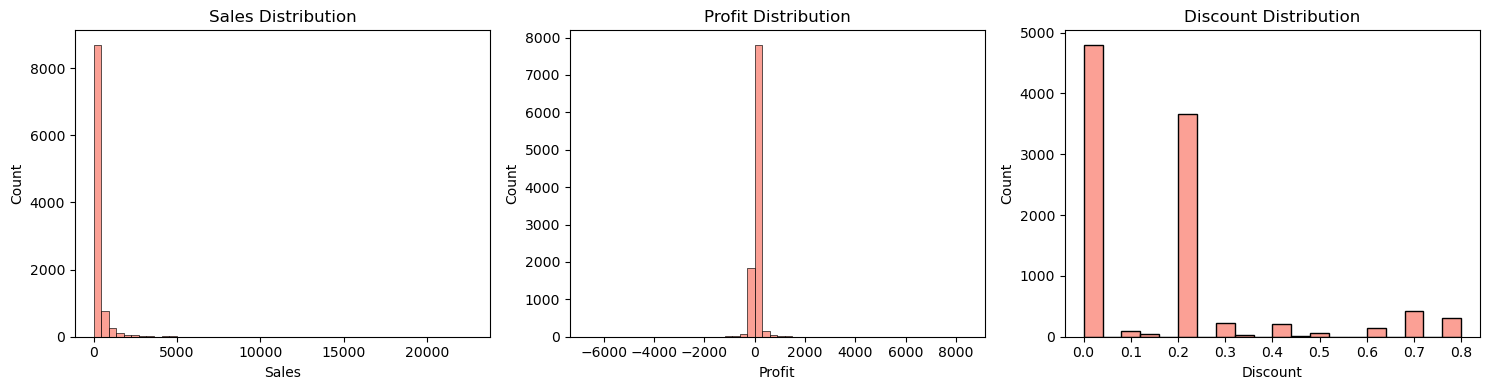

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Sales'], bins=50, ax=axes[0], color='salmon')
axes[0].set_title("Sales Distribution")

sns.histplot(df['Profit'], bins=50, ax=axes[1], color='salmon')
axes[1].set_title("Profit Distribution")

sns.histplot(df['Discount'], bins=20, ax=axes[2], color='salmon')
axes[2].set_title("Discount Distribution")

plt.tight_layout()                                        
plt.savefig("../figures/distributions.png")
plt.show()

# color = company size, geographical EMEA, APJ bla
# log of the count



### Distribution Analysis                    
                                                                                         
  **Sales Distribution / Umsatzverteilung:**                                             
  - Stark rechtsschief (right-skewed, skewness = 12.97) — die meisten Transaktionen sind
  klein                                                                                  
  - Mean ($229.86) ist über 4x höher als der Median ($54.49) — typisches Zeichen für
  Skewness: wenige große Transaktionen ziehen den Durchschnitt nach oben                 
  - 88.4% aller Transaktionen liegen unter $500             
                                                                                         
  > **EN:** Heavily right-skewed (12.97). Mean ($229.86) is 4x the median ($54.49) — a   
  few high-value transactions pull the average up. 88.4% of transactions are below $500. 
                                                                                         
  **Profit Distribution / Gewinnverteilung:**               
  - Ebenfalls rechtsschief (skewness = 7.56), aber mit einem wichtigen Unterschied: der
  Profit geht ins Negative                                                               
  - 18.7% aller Transaktionen (1,871) machen Verlust
  - Median ($8.66) ist deutlich niedriger als der Mean ($28.66) — wieder wenige große    
  Gewinne, die den Schnitt hochziehen                                                    
                                                                                         
  > **EN:** Right-skewed (7.56) but extends into negative territory. 18.7% of all        
  transactions (1,871) result in a loss. Median ($8.66) far below mean ($28.66).
                                                                                         
  **Discount Distribution / Rabattverteilung:**             
  - Keine Normalverteilung — Discounts werden in festen Stufen vergeben, nicht fließend
  - 48% der Transaktionen haben keinen Rabatt (Discount = 0)                             
  - Die häufigste Rabattstufe ist 20% (3,657 Transaktionen)                              
  - Rabatte über 50% existieren (bis 80%) — das sind die Transaktionen, die am ehesten   
  Verlust machen                                                                         
                                                                                         
  > **EN:** Not normally distributed — discounts are applied in fixed tiers, not         
  continuously. 48% of transactions have no discount. The most common tier is 20% (3,657
  transactions). Discounts go up to 80% — these are the most likely loss-makers.

Warum:
  - plt.subplots(1, 3) → 3 Plots nebeneinander in einer Reihe                                                                                                                                                                                                         
  - bins → wie viele "Balken" das Histogramm hat, mehr bins = mehr Detail                                                                                                                                                                                             
  - tight_layout() → verhindert dass sich Labels überlappen              
  - savefig() → speichert den Plot als Bild in figures/                                                                                                                                                                                                               
                                                                                                                                                                                                                                                                      
  Wie liest du die Histogramme:                                                                                                                                                                                                                                       
  - x-Achse = Wert (z.B. Sales-Betrag)                                                                                                                                                                                                                                
  - y-Achse = Wie oft kommt dieser Wert vor                                                                                                                                                                                                                           
  - Wenn die meisten Balken links sind und es einen langen "Schwanz" nach rechts gibt → right-skewed (rechtsschief) — typisch für Sales-Daten (viele kleine, wenige große Transaktionen) 

## Sales & Profit by Region

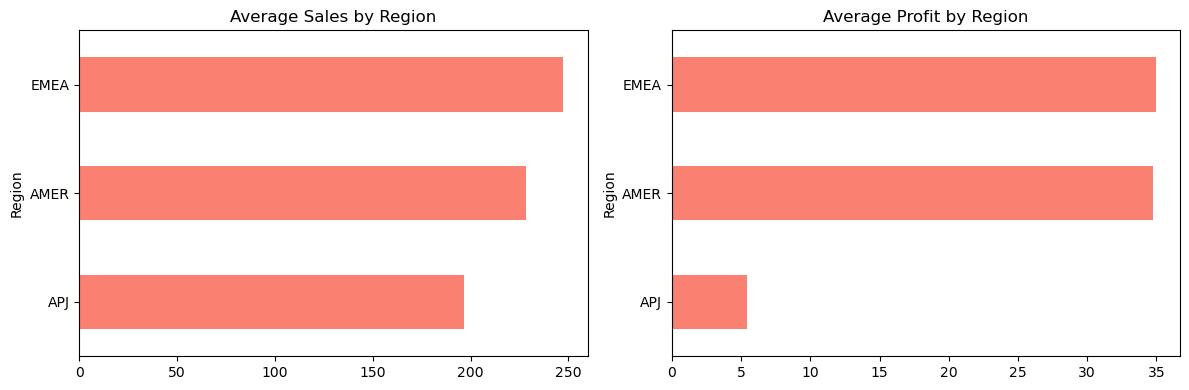

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby("Region")["Sales"].mean().sort_values().plot(kind="barh", ax=axes[0],
color="salmon")
axes[0].set_title("Average Sales by Region")

df.groupby("Region")["Profit"].mean().sort_values().plot(kind="barh", ax=axes[1],
color="salmon")
axes[1].set_title("Average Profit by Region")

plt.tight_layout()
plt.savefig("../figures/sales_profit_by_region.png")
plt.show()

Wie liest du das:
  - Horizontale Balken → längerer Balken = höherer Durchschnitt
  - Vergleich Sales vs Profit pro Region: Wenn eine Region hohe Sales aber niedrigen
  Profit hat, könnte das an hohen Discounts liegen (Spoiler für BQ3!)

## Discount vs Profit Margin by Region 

/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_51251/2158467301.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Region", y="Discount", palette="pastel", ax=axes[0])
/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_51251/2158467301.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Region", y="Profit Margin", palette="pastel", ax=axes[1])


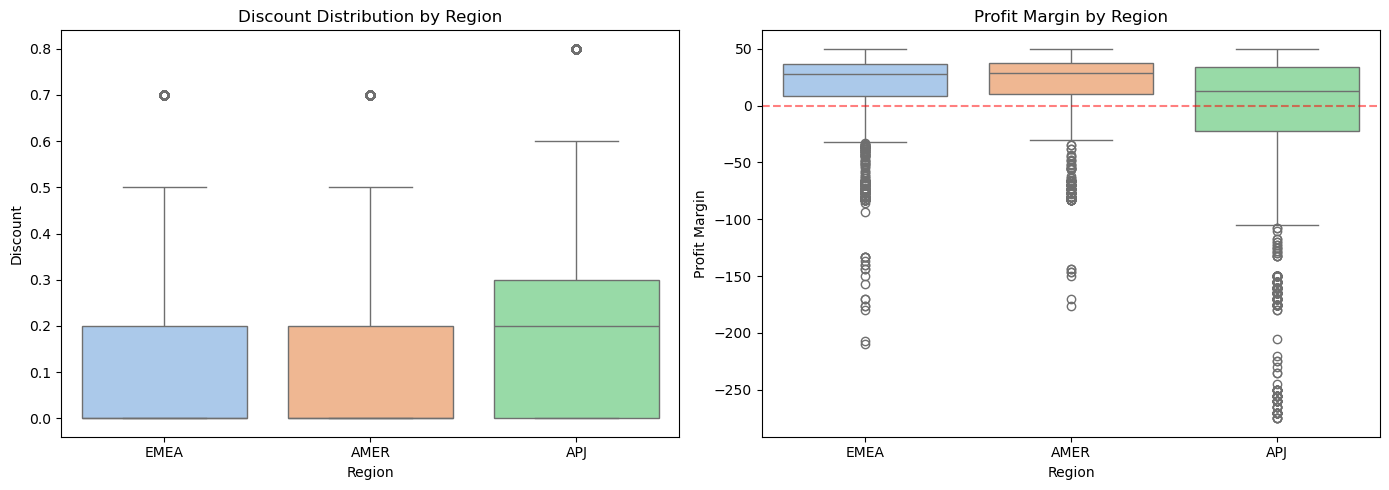

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                        
                                                                                         
# Left: Discount distribution by region                                                
sns.boxplot(data=df, x="Region", y="Discount", palette="pastel", ax=axes[0])           
axes[0].set_title("Discount Distribution by Region")                        
                                                                                         
# Right: Profit Margin by region                                                       
sns.boxplot(data=df, x="Region", y="Profit Margin", palette="pastel", ax=axes[1])
axes[1].set_title("Profit Margin by Region")                                           
axes[1].axhline(y=0, color="red", linestyle="--", alpha=0.5)
                                                                                         
plt.tight_layout()
plt.savefig("../figures/discount_margin_by_region.png")                                
plt.show()  

Warum so:
  - Zwei Boxplots nebeneinander — links Discount, rechts Profit Margin — der Zusammenhang
   wird sofort sichtbar                                                                  
  - axhline(y=0) → rote gestrichelte Linie bei 0% Profit Margin — alles darunter ist     
  Verlust                                                                                
  - APJ sollte links die höchste Box haben (hohe Discounts) und rechts die niedrigste    
  (niedrige/negative Margen) — das erzählt die Story visuell
                                                                                         
  Wie du den Plot liest:                                    
  - Schau wie weit die APJ-Box im linken Plot nach oben geht (hohe Rabatte)              
  - Dann schau im rechten Plot wie weit die APJ-Box unter die rote Linie rutscht         
  (Verluste)                                                                    
  - AMER/EMEA zum Vergleich: niedrige Discounts links, gesunde Margen rechts

## Profit by Segment

/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_51251/2234366345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Segment", y="Profit", palette="pastel")


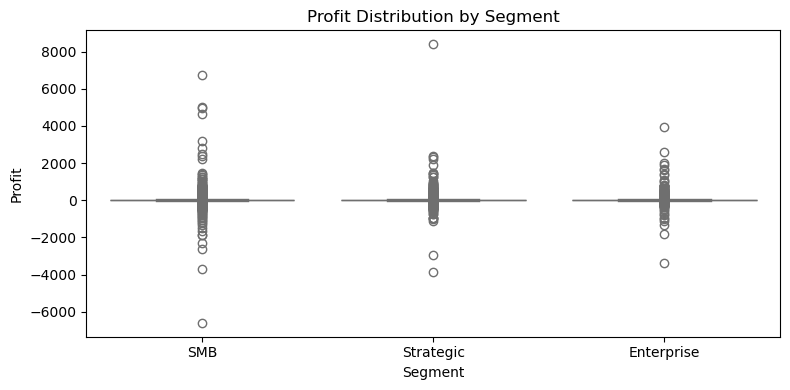

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(data=df, x="Segment", y="Profit", palette="pastel")
ax.set_title("Profit Distribution by Segment")

plt.tight_layout()
plt.savefig("../figures/profit_by_segment.png")
plt.show()

Wie liest du den Boxplot (Kastengrafik):
  - Box = mittlere 50% der Daten (25. bis 75. Perzentil)
  - Linie in der Box = Median
  - Whiskers (die Striche) = Bereich ohne Ausreißer
  - Punkte außerhalb = Outliers (Ausreißer)
  - Vergleich der Boxen zeigt dir ob die Segmente sich deutlich unterscheiden (relevant
  für BQ4)

## Correlation Heatmap

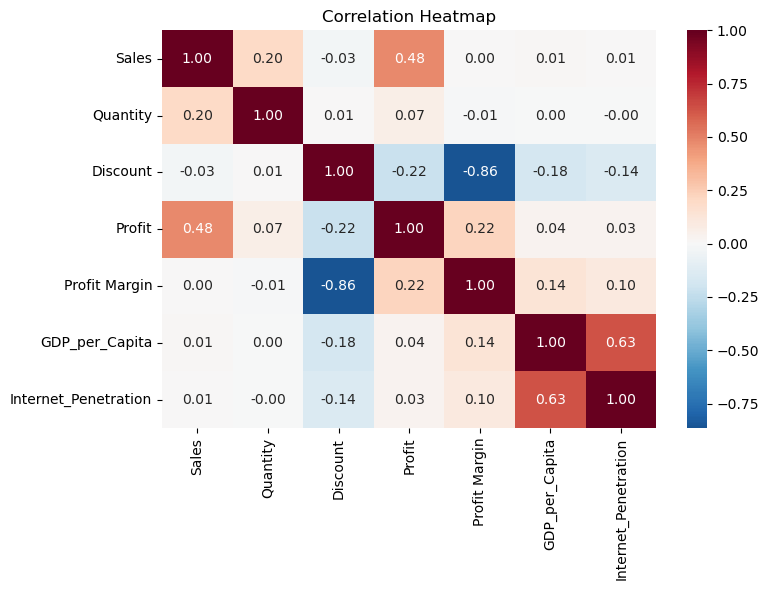

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

numeric_cols = ["Sales", "Quantity", "Discount", "Profit", "Profit Margin",
"GDP_per_Capita", "Internet_Penetration"]
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
ax=ax)
ax.set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png")
plt.show()

Wie liest du die Heatmap:
  - Jede Zelle zeigt den Pearson-Korrelationskoeffizienten zwischen zwei Variablen (-1
  bis +1)
  - +1 (dunkelrot) = perfekter positiver Zusammenhang
  - -1 (dunkelblau) = perfekter negativer Zusammenhang
  - 0 (weiß) = kein linearer Zusammenhang
  - annot=True → zeigt die Zahlen direkt in den Zellen
  - center=0 → weiß ist bei 0, dadurch siehst du sofort was positiv/negativ korreliert
  - Schau besonders auf Discount ↔ Profit — das gibt dir schon einen Vorgeschmack auf
  BQ5!

## World Bank Data: GDP & Internet Penetration by Region

/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_51251/3863929192.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Region", y="GDP_per_Capita", palette="pastel", ax=axes[0])
/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_51251/3863929192.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Region", y="Internet_Penetration", palette="pastel",


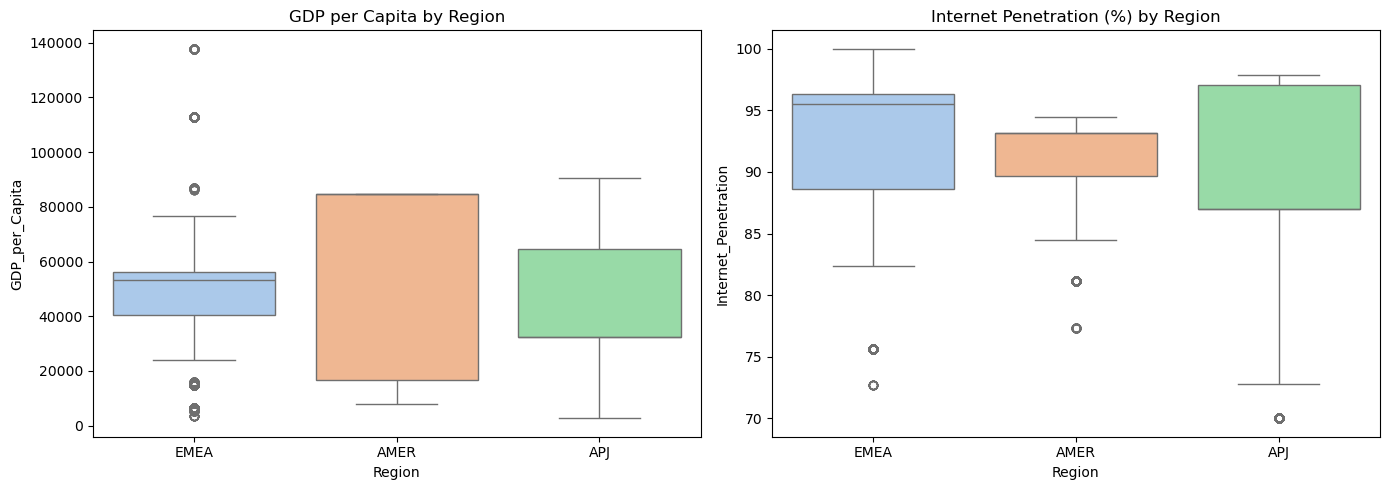

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                                                                                         
sns.boxplot(data=df, x="Region", y="GDP_per_Capita", palette="pastel", ax=axes[0])     
axes[0].set_title("GDP per Capita by Region")                                     
                                                                                         
sns.boxplot(data=df, x="Region", y="Internet_Penetration", palette="pastel",           
ax=axes[1])                                                                 
axes[1].set_title("Internet Penetration (%) by Region")                                
                                                            
plt.tight_layout()                                                                     
plt.savefig("../figures/worldbank_by_region.png")
plt.show()             

Wie du das liest:
  - Zeigt die wirtschaftliche Unterschiede zwischen den Regionen, in denen AWS verkauft  
  - Wenn APJ z.B. niedrigeres GDP hat, erklärt das vielleicht warum dort mehr Discounts  
  nötig sind — Kunden in ärmeren Märkten brauchen Rabatte                                
  - Das ist der Teaser für BQ1 und BQ2 — die genaue statistische Analyse kommt im        
  Hypothesis Testing                                                             
                                                                                         


## EDA Analysis     

  - EMEA = Europe, Middle East & Africa (Europa, Naher Osten & Afrika)
  - AMER = Americas (Nord- & Südamerika)
  - APJ = Asia Pacific & Japan (Asien-Pazifik & Japan)
                                                                                         
  ### 1. Sales & Profit by Region / Umsatz & Gewinn nach Region                          
                                                                                         
  | Region | Avg Sales | Avg Profit | Avg Discount | Transactions |                      
  |--------|-----------|------------|--------------|--------------|                      
  | EMEA   | $247.43   | $34.95     | 14%          | 4,219        |                      
  | AMER   | $228.61   | $34.77     | 11%          | 3,665        |                      
  | APJ    | $196.90   | $5.46      | 27%          | 2,110        |                      
                                                                                         
  **Beobachtung / Observation:**                                                         
  - EMEA und AMER sind fast gleich profitabel (~$35), obwohl EMEA höhere Sales hat       
  - APJ fällt dramatisch ab: fast gleiche Sales wie die anderen, aber nur $5.46 Profit — 
  das ist **85% weniger** als EMEA/AMER                                                  
  - Der Grund springt ins Auge: APJ hat mit 27% einen **doppelt so hohen Discount** wie  
  die anderen Regionen — die Rabatte fressen den Profit                                  
                                                                                         
  > **EN:** APJ shows dramatically lower profit ($5.46 vs ~$35) despite similar sales    
  levels. The likely driver: APJ's average discount (27%) is nearly double that of EMEA  
  (14%) and AMER (11%).                                                                  
                                                                                         
  ---                                                                                    
                                                                                         
  ### 2. Profit by Segment / Gewinn nach Kundensegment

  | Segment    | Avg Sales | Avg Profit | Avg Profit Margin | Transactions |             
  |------------|-----------|------------|-------------------|--------------|
  | Enterprise | $240.97   | $33.82     | 14.29%            | 1,783        |             
  | Strategic  | $233.82   | $30.46     | 12.12%            | 3,020        |             
  | SMB        | $223.73   | $25.84     | 11.20%            | 5,191        |
                                                                                         
  **Beobachtung / Observation:**                            
  - Enterprise-Kunden sind am profitabelsten (höchste Marge: 14.29%), obwohl sie die     
  wenigsten Transaktionen ausmachen                                                      
  - SMB hat die meisten Transaktionen (5,191), aber die niedrigste Marge (11.20%)
  - Die vielen Outliers bei SMB erklären sich durch das hohe Volumen — mehr Transaktionen
   = mehr Extremwerte                                                                    
                                                                                         
  > **EN:** Enterprise customers show the highest profit margin (14.29%) despite having  
  the fewest transactions. SMB dominates in volume but has the lowest margin (11.20%).
  More outliers in SMB are expected due to higher transaction count.                     
                                                            
  ---

  ### 3. Correlation Heatmap / Korrelationsmatrix

  **Wichtigste Korrelationen / Key Correlations:**

  | Variable Pair | r | Interpretation |                                                 
  |---|---|---|
  | Discount ↔ Profit Margin | **-0.85** | Starke negative Korrelation — höherer Rabatt =
   deutlich niedrigere Marge |                                                           
  | Sales ↔ Profit | **+0.48** | Moderate positive Korrelation — mehr Umsatz tendiert zu
  mehr Gewinn |                                                                          
  | GDP per Capita ↔ Internet Penetration | **+0.63** | Erwartbar — reichere Länder haben
   besseren Internetzugang |                                                             
  | Discount ↔ GDP per Capita | **-0.18** | Schwach negativ — ärmere Länder bekommen
  tendenziell höhere Rabatte |                                                           
  | GDP per Capita ↔ Profit Margin | **+0.14** | Schwach positiv — reichere Länder haben
  etwas bessere Margen |                                                                 
                                                            
  **Beobachtung / Observation:**                                                         
  - Die stärkste Korrelation ist **Discount ↔ Profit Margin (-0.85)** — das bestätigt die
   APJ-Beobachtung oben                                                                  
  - **100% aller negativen Profits kommen von rabattierten Transaktionen** (1,871 von
  9,994 = 18.7% aller Transaktionen). Keine einzige Transaktion ohne Rabatt hat Verlust  
  gemacht!                                                  
  - GDP und Internet Penetration korrelieren stark miteinander (0.63) — Vorsicht vor     
  Multikollinearität bei der Analyse                                                     
   
  > **EN:** The strongest signal is Discount ↔ Profit Margin (-0.85). Critically, ALL    
  1,871 negative-profit transactions (18.7%) had a discount applied — zero non-discounted
   transactions resulted in a loss. This strongly supports BQ5. GDP and Internet         
  Penetration correlate at 0.63 — watch for multicollinearity.

  ---                                                                                    
                                                                                         
  ### 4. World Bank Data by Region / Wirtschaftsdaten nach Region                        
                                                                                         
  **Beobachtung / Observation:**                                                         
  - APJ zeigt eine deutlich breitere Streuung beim GDP per Capita — von sehr armen bis
  sehr reichen Ländern in einer Region                                                   
  - AMER hat das höchste GDP per Capita (dominiert durch USA/Kanada), EMEA liegt im
  Mittelfeld                                                                             
  - Internet Penetration ist in AMER und EMEA relativ homogen (>85%), APJ zeigt mehr
  Varianz                                                                                
  - Die Kombination aus niedrigerem GDP und höheren Discounts in APJ deutet darauf hin,
  dass in wirtschaftlich schwächeren Märkten aggressiver rabattiert wird                 
                                                            
  > **EN:** APJ shows the widest GDP spread — from low-income to high-income countries   
  within one region. AMER leads in GDP per capita (driven by US/Canada), EMEA sits in the
   middle. Internet penetration is fairly homogeneous in AMER and EMEA (>85%), while APJ 
  shows more variance. The combination of lower GDP and higher discounts in APJ suggests
  more aggressive discounting in economically weaker markets.

## EDA Summary

### Key Findings                                                                       
                                                                                         
  | # | Finding | Detail |                                                               
  |---|---|---|                                                                          
  | 1 | APJ discount problem | APJ avg discount (27%) is nearly double EMEA (14%) and AMER (11%), crushing profit margins |                                                  
  | 2 | Discounts = losses | 100% of negative-profit transactions (1,871 / 9,994) had a discount applied |                                                                   
  | 3 | Enterprise most profitable | Highest margin (14.29%) despite fewest transactions                                                                                      
  | 4 | Strong negative correlation | Discount ↔ Profit Margin: r = -0.85 |              
  | 5 | GDP & Internet correlated | r = 0.63 — wealthier countries have better internet access |                                                                               
                                                                                         
  ### Preview for Hypothesis Testing                                                     
  | BQ | What EDA suggests |                                                             
  |---|---|                                                 
  | BQ1 (GDP → Profit) | Weak positive signal (r = 0.14) — needs regression to confirm | 
  | BQ2 (Internet → Transactions) | Needs aggregation by country to test properly |     
  | BQ3 (Discount by Region) | Clear visual difference — t-test should confirm |         
  | BQ4 (Profit by Segment) | Small differences visible — ANOVA will tell if significant                                                                                       
  | BQ5 (Discount → Negative Profit) | Strongest signal — 100% of losses come from discounted transactions |